In [2]:
import numpy as np
import scipy
import pandas
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('white')
sns.set_style('ticks')
sns.set_context('notebook')
import h5py
import allel, os
import zarr
import pandas as pd


In [7]:


for chrom in range(4, 15):
    vcf_path = f"/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Maesot_in_out/Inputs/Trial_20inds_forMissingness_depth/cohort_vcf/ABfilt_formask/chr{chrom:02d}_top3_individuals_subset_updated.vcf.gz"
    zarr_path = f"/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Maesot_in_out/Inputs/Trial_20inds_forMissingness_depth/cohort_vcf/cohort_zarrs/chr{chrom:02d}_top3_individuals_subset.zarr"
    if os.path.isfile(vcf_path): allel.vcf_to_zarr(vcf_path, zarr_path, group='AllChr', fields='*', overwrite=True)


In [5]:


callset = {}
for chrom in range(6, 15):
    zarr_path = f"/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Maesot_in_out/Inputs/Trial_20inds_forMissingness_depth/cohort_vcf/cohort_zarrs/chr{chrom:02d}_top3_individuals_subset.zarr"
    if os.path.isdir(zarr_path):
        callset[f'chr{chrom}'] = zarr.open_group(zarr_path, mode='r')['AllChr']


In [8]:
# Collect genotype data for each chromosome into separate entries in a dictionary
gt_data = {f'chr{chrom}': callset[f'chr{chrom}']['calldata/GT'][:] for chrom in range(6, 15) if f'chr{chrom}' in callset}


In [9]:
gt_data

{'chr6': array([[[-1, -1],
         [-1, -1],
         [-1, -1]],
 
        [[-1, -1],
         [ 0,  0],
         [-1, -1]],
 
        [[-1, -1],
         [ 0,  0],
         [-1, -1]],
 
        ...,
 
        [[-1, -1],
         [-1, -1],
         [-1, -1]],
 
        [[-1, -1],
         [-1, -1],
         [-1, -1]],
 
        [[-1, -1],
         [-1, -1],
         [-1, -1]]], dtype=int8),
 'chr7': array([[[-1, -1],
         [-1, -1],
         [-1, -1]],
 
        [[-1, -1],
         [-1, -1],
         [-1, -1]],
 
        [[-1, -1],
         [-1, -1],
         [-1, -1]],
 
        ...,
 
        [[-1, -1],
         [-1, -1],
         [-1, -1]],
 
        [[-1, -1],
         [-1, -1],
         [-1, -1]],
 
        [[-1, -1],
         [-1, -1],
         [-1, -1]]], dtype=int8),
 'chr8': array([[[-1, -1],
         [-1, -1],
         [-1, -1]],
 
        [[-1, -1],
         [-1, -1],
         [-1, -1]],
 
        [[ 0,  0],
         [-1, -1],
         [-1, -1]],
 
        ...,
 
       

Explore the extremely unfiltered vcf

In [10]:
import allel

# Create a dictionary to store genotype arrays for each chromosome
gt_data_arrays = {
    f'chr{chrom}': allel.GenotypeArray(callset[f'chr{chrom}']['calldata/GT'])
    for chrom in range(6, 15) if f'chr{chrom}' in callset
}

# Access example: gt_data_arrays['chr6']


In [11]:


# Dictionary to store VariantChunkedTable for each chromosome in 'callset_white'
variants = {
    f'chr{chrom}': allel.VariantChunkedTable(
        callset[f'chr{chrom}']['variants'],
        names=['POS', 'CHROM', 'numalt', 'REF', 'ALT', 'DP', 'MQ', 'QD', 'is_snp']
    )
    for chrom in range(6, 15) if f'chr{chrom}' in callset
}


In [12]:
variants['chr9'][:100000]

<VariantTable shape=(100000,) dtype=(numpy.record, [('POS', '<i4'), ('CHROM', 'O'), ('numalt', '<i4'), ('REF', 'O'), ('ALT', 'O', (3,)), ('DP', '<i4'), ('MQ', '<f4'), ('QD', '<f4'), ('is_snp', '?')])>
[(     1, 'Pf3D7_09_v3', 0, 'A', ['', '', ''],    6, nan, nan, False)
 (     2, 'Pf3D7_09_v3', 0, 'A', ['', '', ''],    6, nan, nan, False)
 (     3, 'Pf3D7_09_v3', 0, 'C', ['', '', ''],    7, nan, nan, False) ...
 ( 99998, 'Pf3D7_09_v3', 0, 'C', ['', '', ''], 1298, nan, nan, False)
 ( 99999, 'Pf3D7_09_v3', 0, 'T', ['', '', ''], 1299, nan, nan, False)
 (100000, 'Pf3D7_09_v3', 0, 'T', ['', '', ''], 1299, nan, nan, False)]

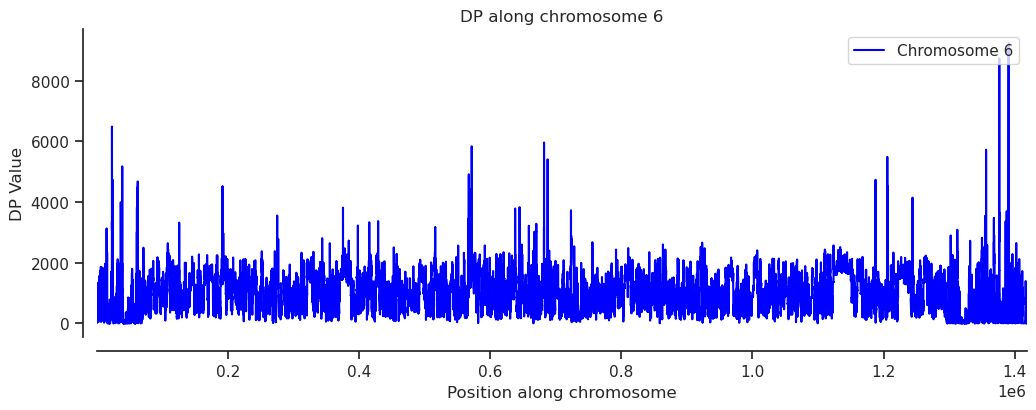

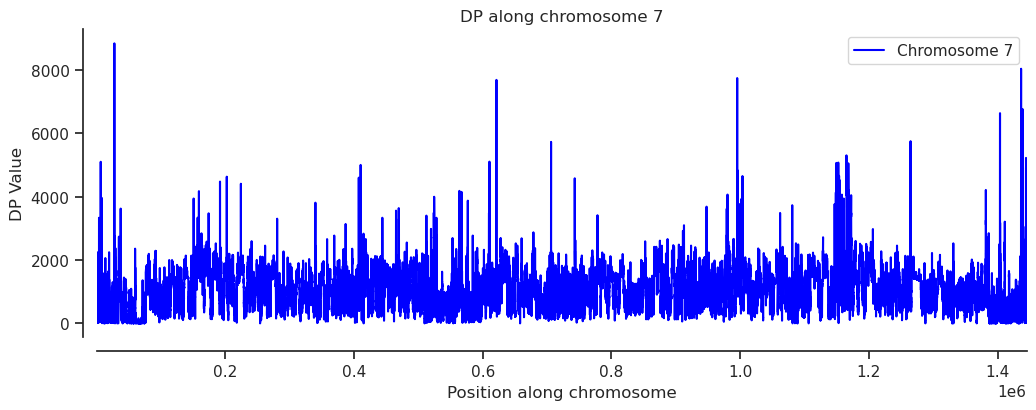

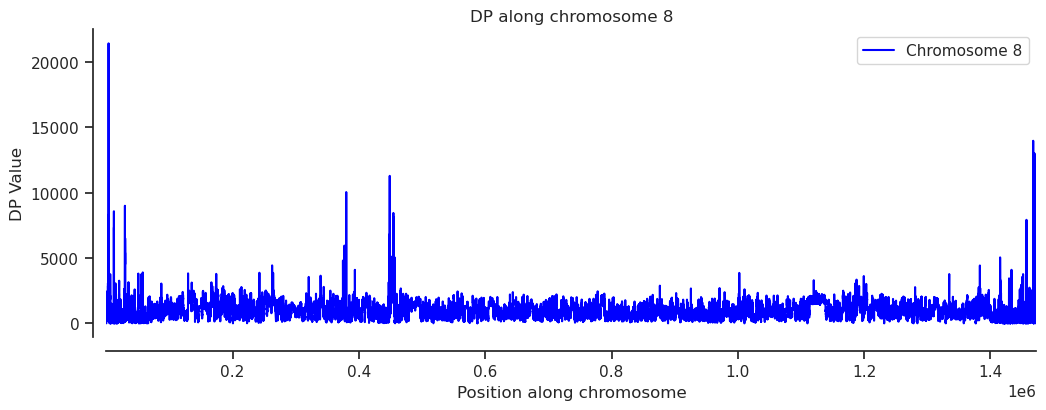

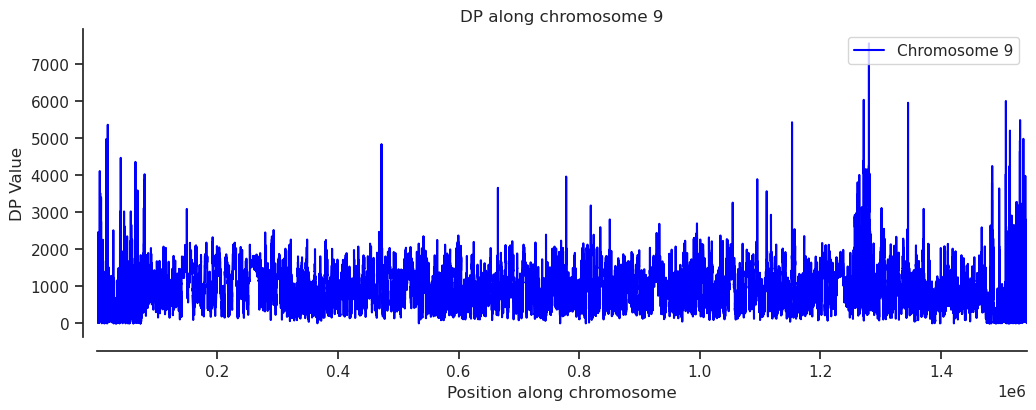

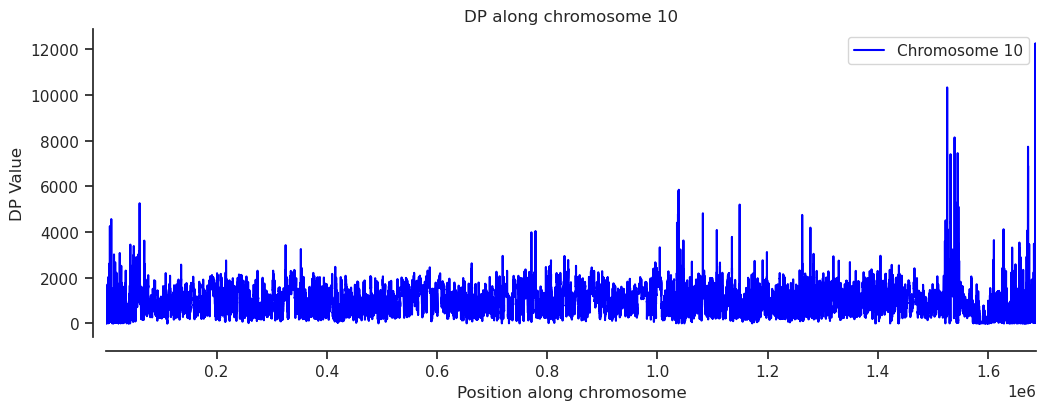

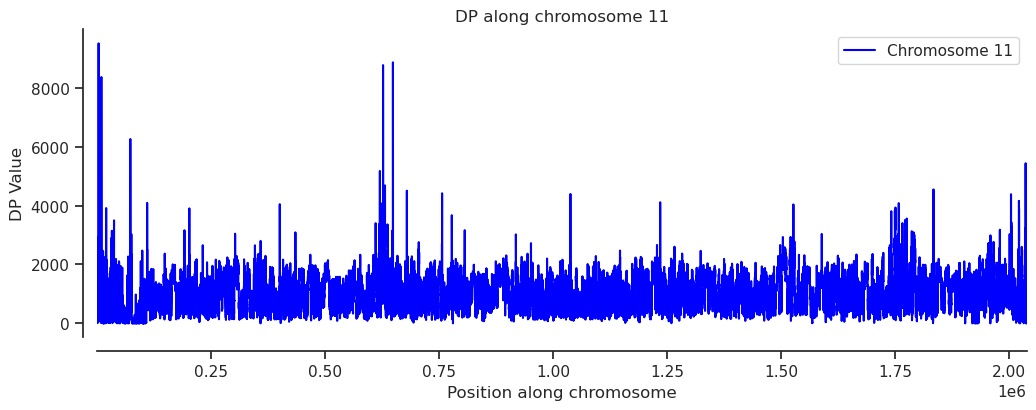

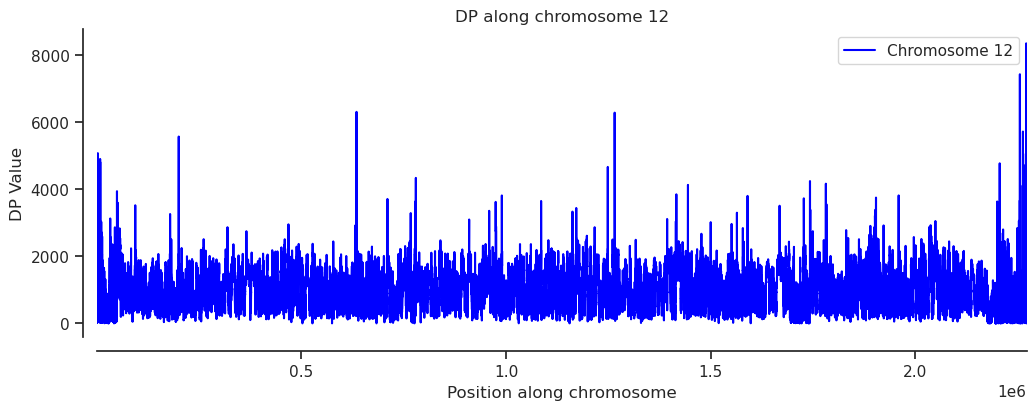

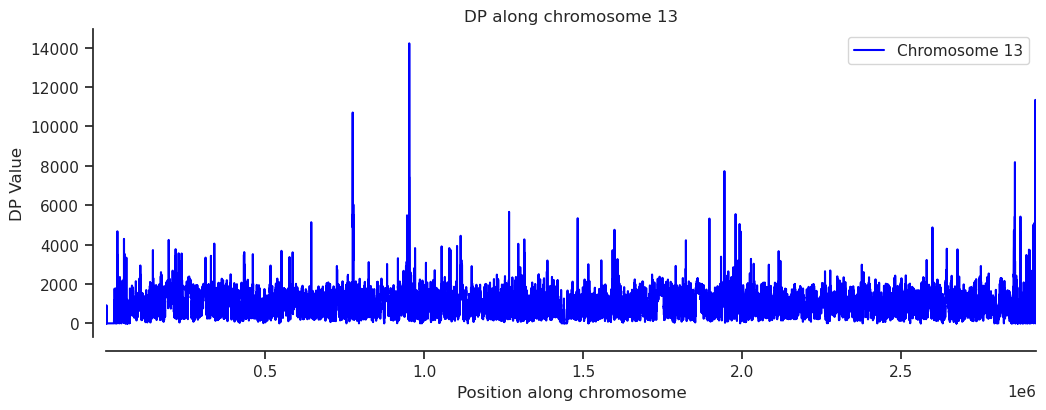

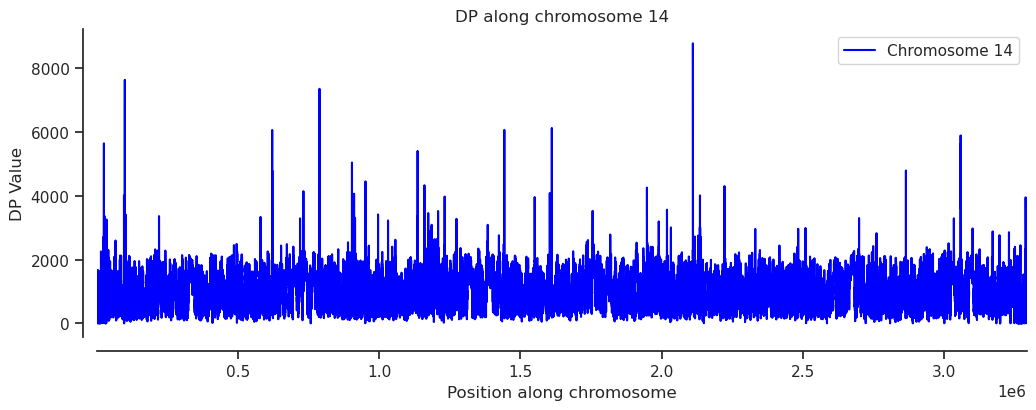

In [10]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_variant_along_chr(f, chroms, variants):
    # Loop through each specified chromosome
    for chrom in chroms:
        # Ensure the chromosome data is available in the variants dictionary
        chrom_key = f'chr{chrom}'
        if chrom_key not in variants:
            print(f"Chromosome {chrom} data not found in variants.")
            continue
        
        # Set up the figure for plotting
        fig, ax = plt.subplots(figsize=(12, 4))
        sns.despine(ax=ax, offset=10)
        
        # Access chromosome-specific data
        chrom_data = variants[chrom_key]
        
        # Extract 'POS' and the specified field 'f' as arrays
        pos = chrom_data['POS'][:]
        field_data = chrom_data[f][:]

        # Plot the feature 'f' along the chromosome
        ax.plot(pos, field_data, label=f'Chromosome {chrom}', color='blue')
        
        ax.set_xlim(min(pos), max(pos))
        ax.set_xlabel('Position along chromosome')
        ax.set_ylabel(f'{f} Value')
        ax.set_title(f'{f} along chromosome {chrom}')
        
        plt.legend(loc='upper right')
        plt.show()

# Example usage: Plot a specific variant feature along chromosomes 6 to 14
chroms = range(6, 15)
plot_variant_along_chr(f='DP', chroms=chroms, variants=variants)

    

In [11]:
%%time
# Initialize dictionaries to store the results for each chromosome
pc_missing_all = {}


# Loop through each chromosome and calculate statistics
for chrom in range(6, 15):
    chrom_key = f'chr{chrom}'
    
    # Ensure the chromosome data exists in both variants and genotypes
    if chrom_key in variants and chrom_key in gt_data_arrays:
        # Get the number of variants in this chromosome
        n_variants = len(variants[chrom_key]['POS'][:])
        print(f"No of variants: {n_variants}")
        # Calculate percentage of missing genotypes for this chromosome
        pc_missing = gt_data_arrays[chrom_key].count_missing(axis=0)[:] * 100 / n_variants
        pc_missing_all[chrom_key] = pc_missing
        
        
        
        # Output (optional): print or store any intermediate results if needed
        print(f"Chromosome {chrom}: Missing % calculated: {pc_missing}.")

# At the end, you have two dictionaries:
# pc_missing_all: holds the percentage of missing genotypes per chromosome
# pc_het_all: holds the percentage of heterozygous genotypes per chromosome


No of variants: 1418242
Chromosome 6: Missing % calculated: [6.46427055 6.32797506 6.43797039].
No of variants: 1445207
Chromosome 7: Missing % calculated: [6.60362149 6.01782305 6.4533316 ].
No of variants: 1472805
Chromosome 8: Missing % calculated: [4.29065626 4.46848021 4.26329351].
No of variants: 1541735
Chromosome 9: Missing % calculated: [3.81077163 3.53582166 3.68169627].
No of variants: 1687656
Chromosome 10: Missing % calculated: [4.60064136 4.16885906 4.37512147].
No of variants: 2038340
Chromosome 11: Missing % calculated: [3.75413327 3.62873711 3.71414975].
No of variants: 2271494
Chromosome 12: Missing % calculated: [3.92767932 3.70791206 4.04812868].
No of variants: 2925235
Chromosome 13: Missing % calculated: [3.69809605 3.8820129  4.06257959].
No of variants: 3291936
Chromosome 14: Missing % calculated: [1.59237604 1.52824964 1.74647988].
CPU times: user 1.05 s, sys: 36.2 ms, total: 1.09 s
Wall time: 1.18 s


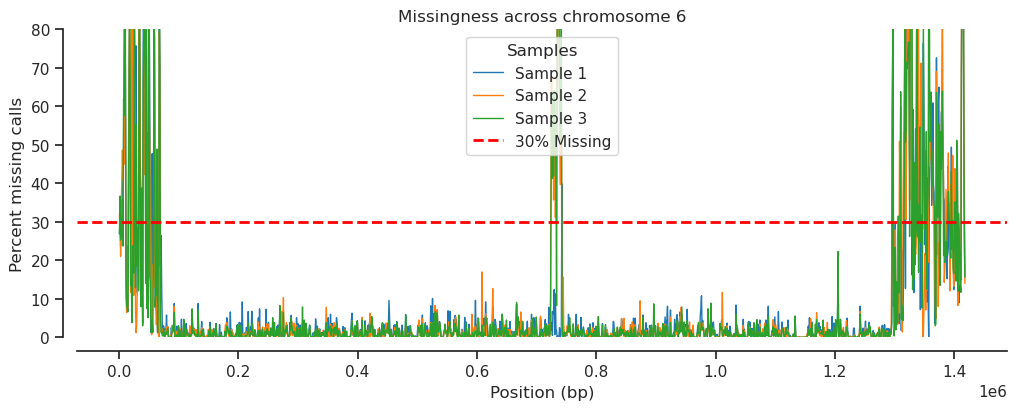

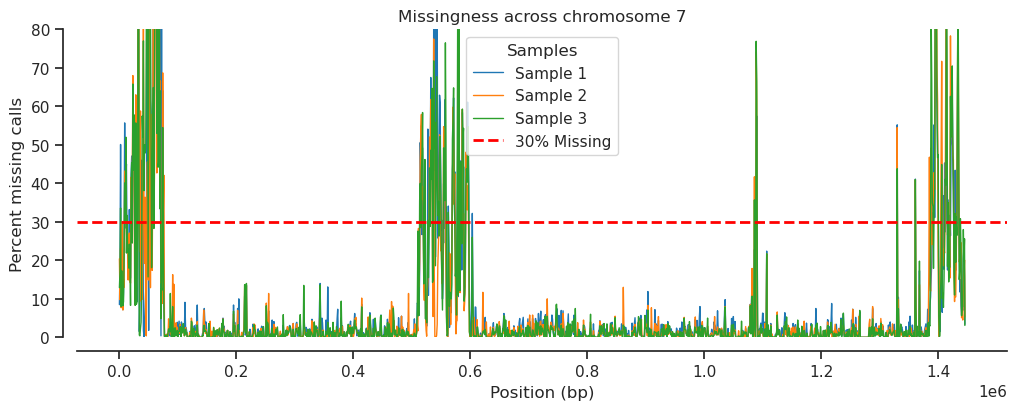

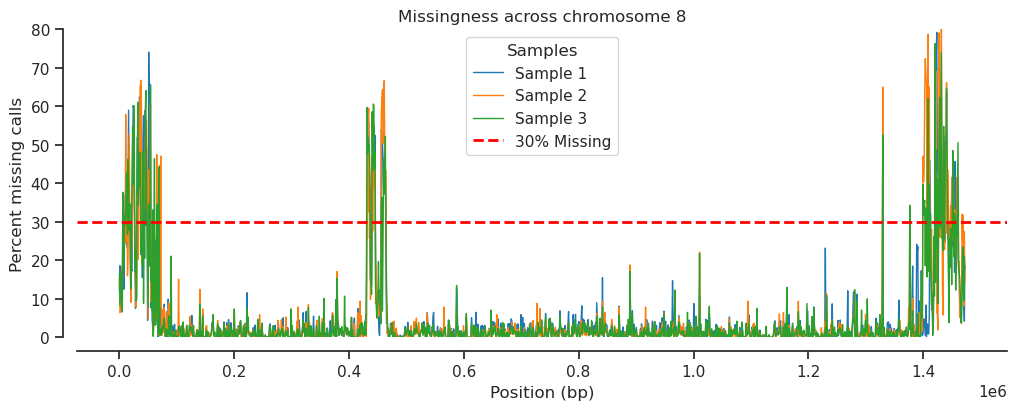

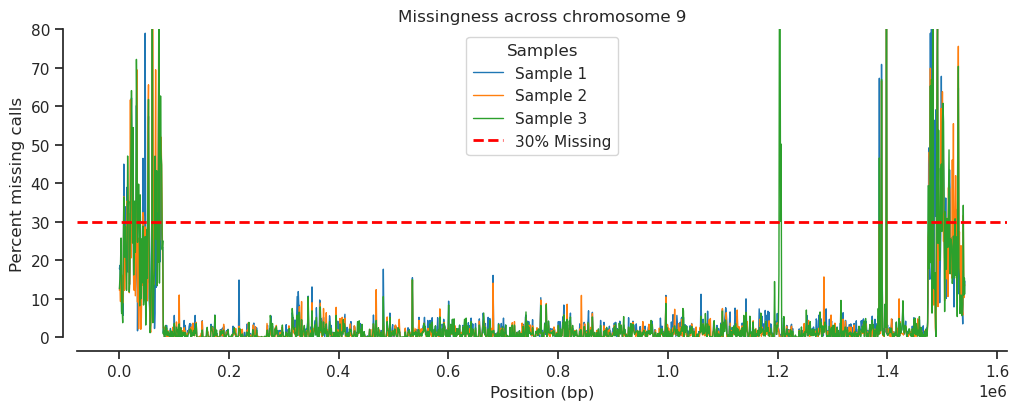

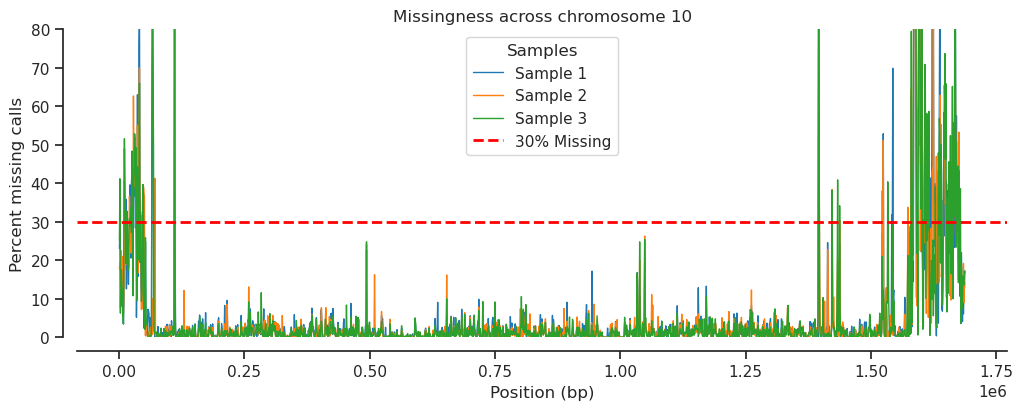

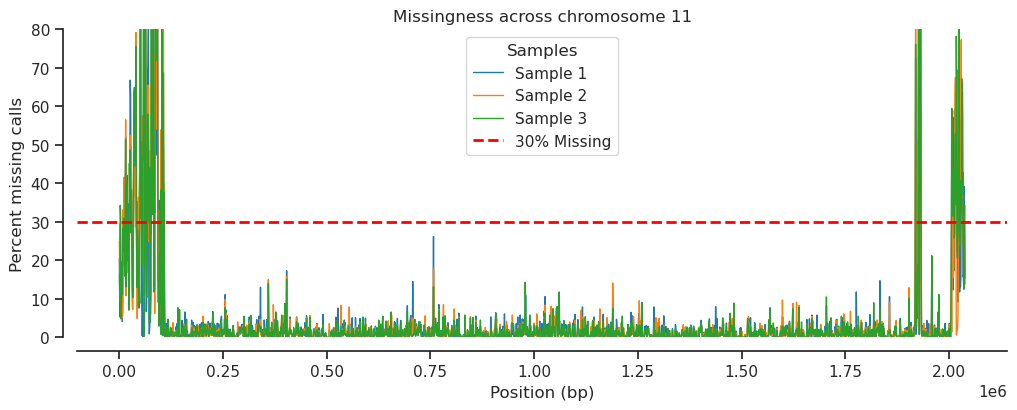

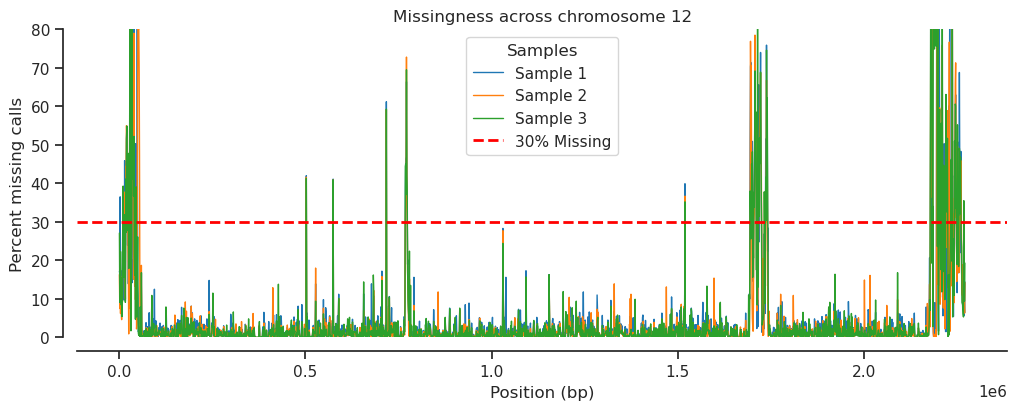

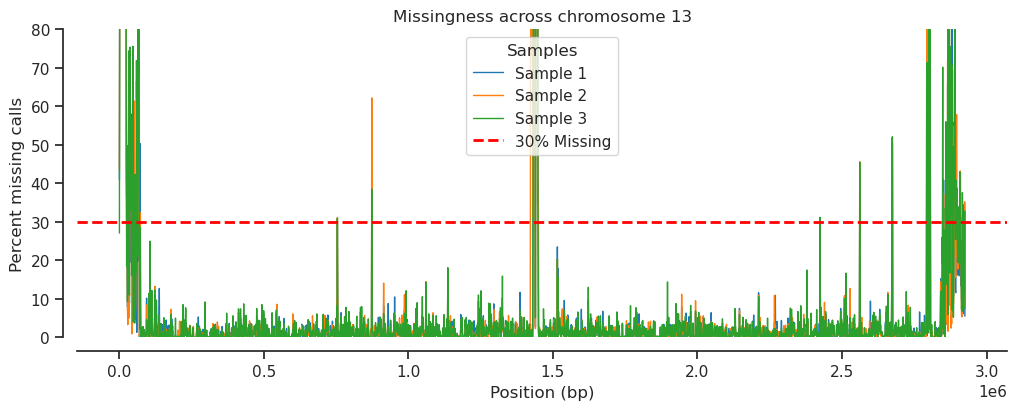

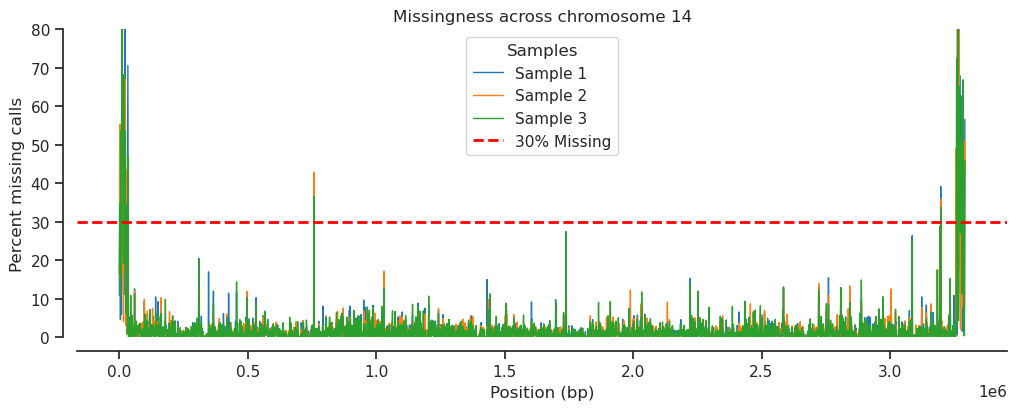

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import allel

# Define the window size
window_size = 1000

# Loop through each chromosome (e.g., chromosomes 6 to 14)
for chrom in range(6, 15):
    chrom_key = f'chr{chrom}'
    
    # Check if chromosome data exists in variants and gt_data_arrays
    if chrom_key in variants and chrom_key in gt_data_arrays:
        pos = variants[chrom_key]['POS'][:]
        is_missing = gt_data_arrays[chrom_key].is_missing()  # Boolean array of missing calls

        # Calculate the missingness percentage per individual in windows
        y_values = []
        for i in range(is_missing.shape[1]):  # Loop over each individual/sample
            y, windows, _ = allel.windowed_statistic(
                pos, is_missing[:, i], statistic=np.count_nonzero, size=window_size  # counts all 'trues' for 'is missing'
            )
            y_values.append(y * 100 / window_size)
        
        # Calculate the mean positions of each window for the x-axis
        x = windows.mean(axis=1)

        # Plot results for each chromosome
        fig, ax = plt.subplots(figsize=(12, 4))
        sns.despine(ax=ax, offset=10)
        
        # Plot each individual's missingness as a separate line
        for i, y in enumerate(y_values):
            ax.plot(x, y, lw=1, label=f'Sample {i + 1}')
        
        # Add a red dotted line at 30% on the y-axis
        ax.axhline(30, color='red', linestyle='--', linewidth=2, label='30% Missing')

        ax.set_xlabel('Position (bp)')
        # ax.set_xlim(200000,1000000)  # Uncomment and adjust if needed
        ax.set_ylim(0, 80)
        ax.set_ylabel('Percent missing calls')
        ax.set_title(f'Missingness across chromosome {chrom}')
        ax.legend(title='Samples')

        plt.show()



In [116]:
#print(pc_missing)

indices = np.where(pc_missing > 2)[0]

print( [1, *indices, 209])

[1, 23, 24, 27, 33, 35, 50, 54, 56, 81, 88, 110, 118, 122, 136, 153, 167, 170, 182, 202, 209]


In [117]:
#print(pc_missing)

indices = np.where(pc_missing > 2)[0]

print([1,indices,209])

print("Indices where pc_missing > 2:", indices)
g_strange = genotypes_subset.take([1, *indices, 209], axis=1)
g_strange
is_missing = g_strange.is_missing()[:]
is_missing

[1, array([ 23,  24,  27,  33,  35,  50,  54,  56,  81,  88, 110, 118, 122,
       136, 153, 167, 170, 182, 202]), 209]
Indices where pc_missing > 2: [ 23  24  27  33  35  50  54  56  81  88 110 118 122 136 153 167 170 182
 202]


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ...,  True, False, False],
       [False, False, False, ...,  True, False, False],
       [False, False, False, ...,  True, False, False]])